#### Import required python packages

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

#### Import sample data

In [4]:
my_df = pd.read_csv("data/sample_data_clustering.csv")
print(my_df)

         var1      var2
0    0.528827  0.919833
1    0.715373  0.133577
2    0.686088  0.824129
3    0.214553  0.609016
4    0.202000  0.486103
..        ...       ...
295  0.462960  0.791974
296  0.326000  0.715142
297  0.718920  0.149854
298  0.544617  0.732966
299  0.475941  0.583227

[300 rows x 2 columns]


#### Plot the data

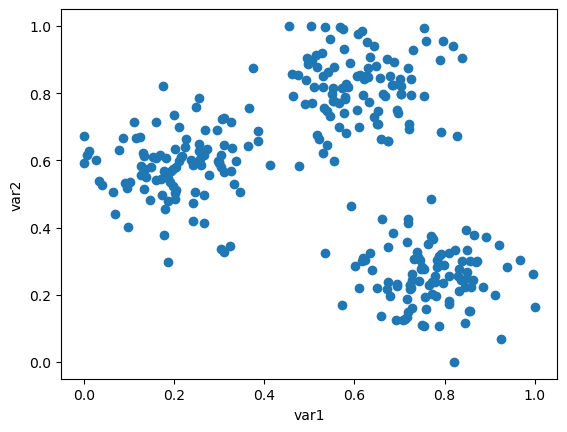

In [5]:
plt.scatter(my_df["var1"], my_df["var2"])
plt.xlabel("var1")
plt.ylabel("var2")
plt.show()

#### Instantiate and fit the model

In [7]:
kmeans = KMeans(n_clusters = 3, random_state = 42)
kmeans.fit(my_df)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


#### Add the cluster labels to our df

In [8]:
my_df["cluster"] = kmeans.labels_
my_df["cluster"].value_counts()

cluster
0    100
2    100
1    100
Name: count, dtype: int64

#### Plot our clusters and centroids

In [9]:
centroids = kmeans.cluster_centers_
print(centroids)

[[0.61145409 0.82340359]
 [0.20990899 0.58086933]
 [0.76730971 0.25649517]]


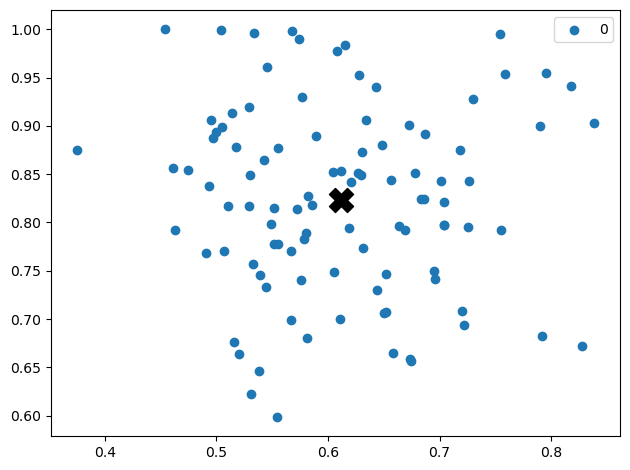

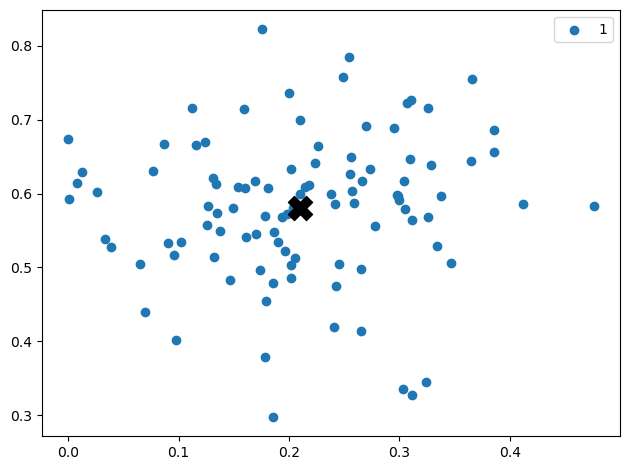

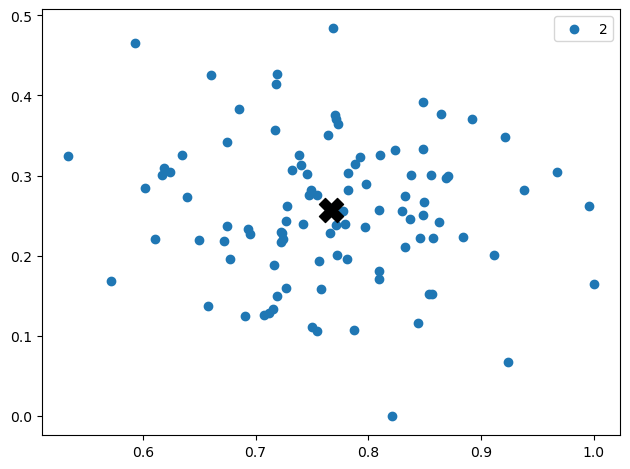

In [10]:
clusters = my_df.groupby("cluster")

for cluster, data in clusters:
    plt.scatter(data["var1"], data["var2"], marker = "o", label = cluster)
    plt.scatter(centroids[cluster,0], centroids[cluster,1], marker = "X", color = "black", s = 300)
plt.legend()
plt.tight_layout()
    plt.show()